# Artificial Intelligence & Machine Learning - Task 4

## Classification Models, Evaluation Metrics & Handling Imbalanced Data

### Objective
- Understand classification problems
- Train and evaluate classification models
- Use evaluation metrics beyond accuracy
- Handle class imbalance
- Compare different models

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

## Step 1: Load Dataset

We use the Breast Cancer dataset for binary classification:
- 0 → Malignant
- 1 → Benign

In [5]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Step 2: Train-Test Split

We split the dataset into training and testing sets.
Stratification is used to maintain class balance.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Step 3: Feature Scaling

StandardScaler is used to normalize features.
This improves performance for models like Logistic Regression.

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 4: Train Logistic Regression Model

This is our baseline classification model.

In [11]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

## Step 5: Confusion Matrix & Classification Report

### Definitions:
- True Positive (TP): Correct positive predictions
- False Positive (FP): Incorrect positive predictions
- False Negative (FN): Missed positive cases

Accuracy alone is not sufficient because it can be misleading,
especially in imbalanced datasets.

In [13]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Confusion Matrix:
 [[41  1]
 [ 1 71]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Step 6: ROC Curve & AUC

- ROC Curve shows model performance across thresholds
- AUC represents model's ability to distinguish classes
- Higher AUC → Better model

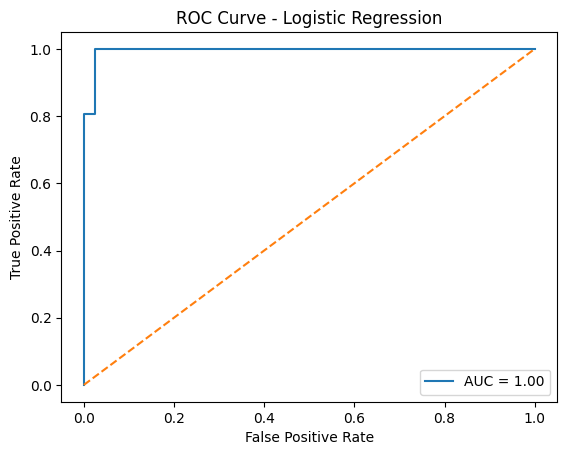

In [15]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

## Step 7: Handling Class Imbalance

We use class_weight="balanced" to give importance to minority class.

In [17]:
model_balanced = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)

print("Balanced Model Report:\n")
print(classification_report(y_test, y_pred_balanced))

Balanced Model Report:

              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



## Step 8: Decision Tree Classifier

We compare Logistic Regression with Decision Tree.

In [19]:
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("Decision Tree Report:\n")
print(classification_report(y_test, y_pred_tree))

Decision Tree Report:

              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



## Final Conclusion

- Logistic Regression provides stable and reliable performance
- Decision Tree may overfit but is easy to interpret
- ROC-AUC helps evaluate model discrimination ability
- F1-score is preferred for imbalanced datasets
- Class weighting improves minority class prediction

### Final Model Choice:
Logistic Regression is preferred due to better generalization.